In [ ]:
xd

# Put the parent directory in path so we can import ERPtools
sys.path.append(os.path.abspath('..'))
from ERPtools import BANDS, process_band_states



In [2]:

with open('/Users/bowmannovey/Desktop/Gangully_Proj/Decay/long_data.pkl', 'rb') as f:
    long_data = pickle.load(f)

# Optional: Ensure it's a flat dict of { "unique_id": mat_file_dict } 
# compatible with process_band_states()
all_long_combined = {}
for date_folder, sessions in long_data.items():
    for session, files in sessions.items():
        # Using a unified SessionID instead of path-strings
        key = f"Day_{date_folder[-4:]}_Block_{session}" 
        all_long_combined[key] = files

print(f"Total sessions extracted: {len(all_long_combined)}")

Total sessions extracted: 18


Processing Delta...
  [Delta] Processing trial 1
  [Delta] Processing trial 2
  [Delta] Processing trial 3
  [Delta] Processing trial 4
  [Delta] Processing trial 5
  [Delta] Processing trial 6
  [Delta] Processing trial 7
  [Delta] Processing trial 8
  [Delta] Processing trial 9
  [Delta] Processing trial 10
  [Delta] Processing trial 11
  [Delta] Processing trial 12
  [Delta] Processing trial 13
  [Delta] Processing trial 14
  [Delta] Processing trial 15
  [Delta] Processing trial 16
  [Delta] Processing trial 17
  [Delta] Processing trial 18
  [Delta] Processing trial 19
  [Delta] Processing trial 20
  [Delta] Processing trial 21
  [Delta] Processing trial 22
  [Delta] Processing trial 23
  [Delta] Processing trial 24
  [Delta] Processing trial 25
  [Delta] Processing trial 26
  [Delta] Processing trial 27
  [Delta] Processing trial 28
  [Delta] Processing trial 29
  [Delta] Processing trial 30
  [Delta] Processing trial 31
  [Delta] Processing trial 32
  [Delta] Processing trial 33

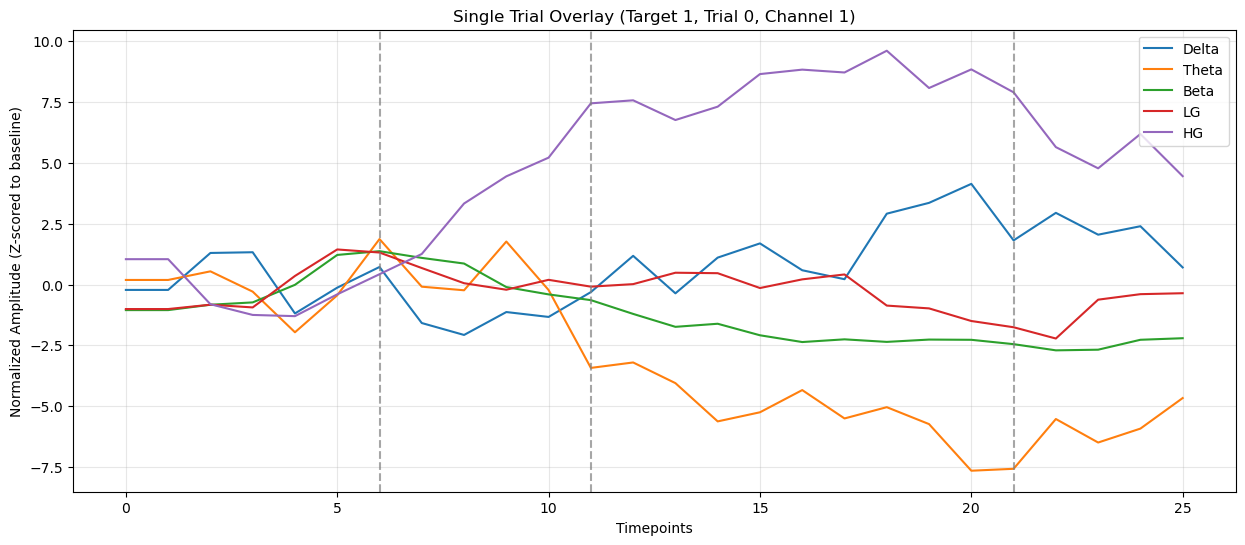

In [3]:

# 2. Process all bands
all_band_results = {}
for band_name, (start_idx, end_idx) in BANDS.items():
    print(f"Processing {band_name}...")
    D_dict, _, state_lengths = process_band_states(all_long_combined, band_name, start_idx, end_idx)
    all_band_results[band_name] = {
        'D': D_dict,
        'state_lengths': state_lengths
    }

# 3. Define a custom function to plot a single trial overlay
def plot_single_trial_overlay(results, target_id, trial_idx, ch_idx=0):
    """
    Overlays all frequency bands for a single trial on a specific channel.
    ch_idx is 0-indexed (Channel 1 -> ch_idx=0)
    """
    plt.figure(figsize=(15, 6))
    
    # We'll use the state boundaries from the first band (they are the same for all)
    first_band = list(results.keys())[0]
    lengths = results[first_band]['state_lengths']
    boundaries = np.cumsum(lengths[:-1]) if lengths else []
    
    for band_name, res in results.items():
        D_target = res['D'][target_id]
        
        # Check if we have data for this target and if the trial exists
        if D_target.size == 0:
            continue
        if trial_idx >= D_target.shape[2]:
            print(f"Trial {trial_idx} out of bounds for {band_name} (max trials: {D_target.shape[2]})")
            continue
            
        # D_target shape: (channels, time, trials)
        trial_data = D_target[ch_idx, :, trial_idx]
        
        # Optional: Z-score the single trial data to baseline (first 8 points) so bands are on similar scales
        baseline = trial_data[:8]
        trial_data_norm = (trial_data - np.mean(baseline)) / (np.std(baseline) + 1e-10)
        
        plt.plot(trial_data_norm, label=band_name, linewidth=1.5)

    # Plot vertical lines for states
    for b in boundaries:
        plt.axvline(x=b, color='gray', linestyle='--', alpha=0.7)

    plt.title(f'Single Trial Overlay (Target {target_id}, Trial {trial_idx}, Channel {ch_idx+1})')
    plt.xlabel('Timepoints')
    plt.ylabel('Normalized Amplitude (Z-scored to baseline)')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.show()

# 4. Try plotting! Example: Target 1, Trial 0 (first trial), Channel 0 (first channel)
plot_single_trial_overlay(all_band_results, target_id=1, trial_idx=0, ch_idx=0)

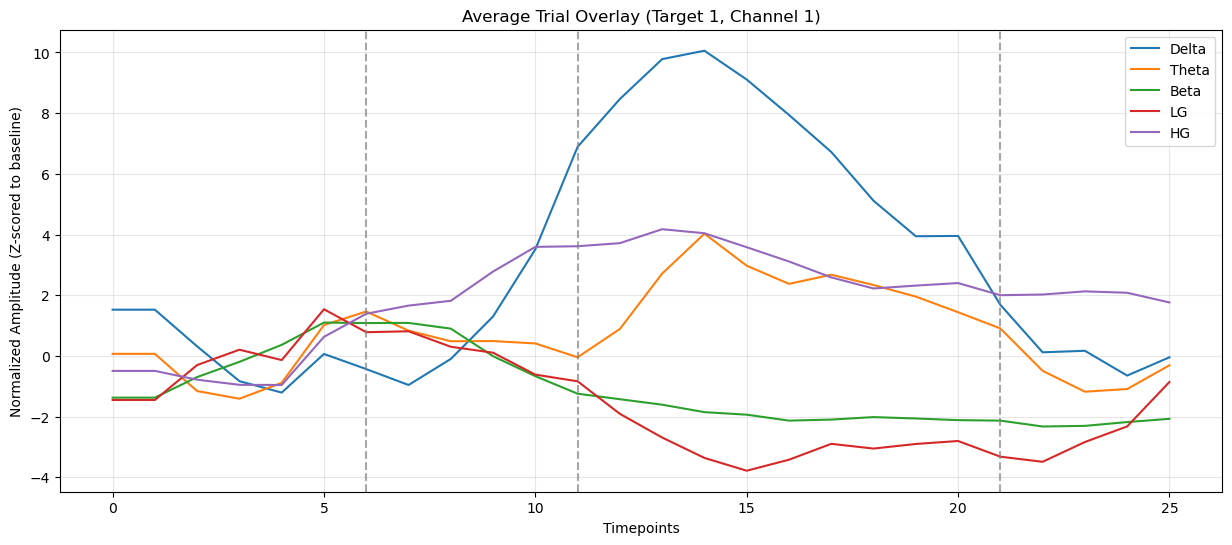

In [5]:
def plot_average_trial_overlay(results, target_id, ch_idx=0):
    """
    Overlays all frequency bands averaged across all trials for a specific channel.
    ch_idx is 0-indexed (Channel 1 -> ch_idx=0)
    """
    plt.figure(figsize=(15, 6))
    
    # We'll use the state boundaries from the first band
    first_band = list(results.keys())[0]
    lengths = results[first_band]['state_lengths']
    boundaries = np.cumsum(lengths[:-1]) if lengths else []
    
    for band_name, res in results.items():
        D_target = res['D'][target_id]
        
        if D_target.size == 0:
            continue
            
        # D_target shape: (channels, time, trials)
        # Average across the trial dimension (axis 2) for the specific channel
        avg_data = np.mean(D_target[ch_idx, :, :], axis=1)
        
        # Z-score the averaged data to baseline (first 8 points)
        baseline = avg_data[:8]
        avg_data_norm = (avg_data - np.mean(baseline)) / (np.std(baseline) + 1e-10)
        
        plt.plot(avg_data_norm, label=band_name, linewidth=1.5)

    # Plot vertical lines for states
    for b in boundaries:
        plt.axvline(x=b, color='gray', linestyle='--', alpha=0.7)

    plt.title(f'Average Trial Overlay (Target {target_id}, Channel {ch_idx+1})')
    plt.xlabel('Timepoints')
    plt.ylabel('Normalized Amplitude (Z-scored to baseline)')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.show()

# Plot the average overlay for Target 1, Channel 0 (averaged across all trials)
plot_average_trial_overlay(all_band_results, target_id=1, ch_idx=0)